<a href="https://colab.research.google.com/github/finn-mcduffee8/IT480-FA26/blob/main/Assignment2_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *(Finn McDuffee)*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [4]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: finnmcduffee
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:14<00:00, 28.3MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [5]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [6]:
# Your exploration here
# Count images in each class folder
for class_name in class_names_fire:
    class_path = os.path.join(data_dir_fire, class_name)
    num_images = len(os.listdir(class_path))
    print(f"{class_name}: {num_images} images")


fire_images: 755 images
non_fire_images: 244 images


*What did you notice about this dataset? Does it change how you'll approach the next steps?*



## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [7]:
# Preprocess the data here
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_fire = train_raw_fire.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

val_fire = val_raw_fire.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

test_fire = test_raw_fire.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)


In [8]:
# Build your model here

base_model_fire = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model_fire.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model_fire(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model_fire = tf.keras.Model(inputs, outputs)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
# Compile your model here
model_fire.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


## 1D — Train and Evaluate

In [10]:
# Train your model here
history_fire = model_fire.fit(
    train_fire,
    validation_data=val_fire,
    epochs=10
)


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.7314 - loss: 0.5059 - val_accuracy: 0.8849 - val_loss: 0.3072
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9543 - loss: 0.1870 - val_accuracy: 0.9496 - val_loss: 0.1782
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9671 - loss: 0.1190 - val_accuracy: 0.9496 - val_loss: 0.1424
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9800 - loss: 0.0946 - val_accuracy: 0.9856 - val_loss: 0.0963
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9814 - loss: 0.0800 - val_accuracy: 0.9712 - val_loss: 0.0887
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9900 - loss: 0.0706 - val_accuracy: 0.9712 - val_loss: 0.0987
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9886 - loss: 0.0627 - val_accuracy: 0.9712 - val_loss: 0.1023
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9929 - loss: 0.0573 - val_accuracy: 0.9712 - val_loss:

In [11]:
# Report validation and test accuracy here
val_loss, val_accuracy = model_fire.evaluate(val_fire)
test_loss, test_accuracy = model_fire.evaluate(test_fire)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 914ms/step - accuracy: 0.9712 - loss: 0.0781
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9750 - loss: 0.0841
Validation Accuracy: 0.9712
Test Accuracy: 0.9750


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

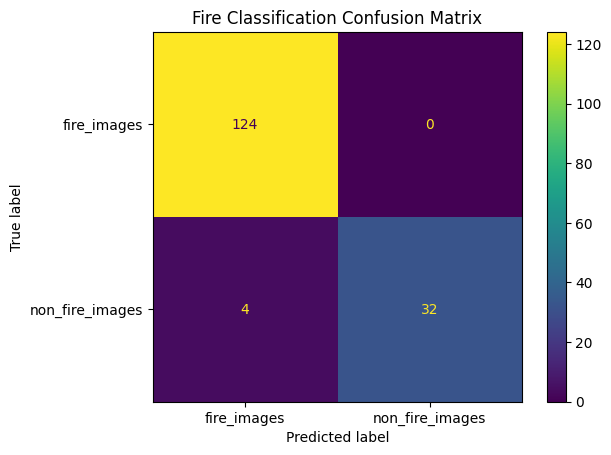

In [12]:
# Build your confusion matrix here
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_fire:
    predictions = model_fire(images, training=False)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions.numpy().flatten() >= 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names_fire
)

disp.plot()
plt.title("Fire Classification Confusion Matrix")
plt.show()


*Your answer:*
A false negative to miss a real fire would be more costly which would lead me to raise the decision threshold above 0.5 so the model is more confident in predicting non-fires.



---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [13]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [14]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [15]:
# Preprocess the data here
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_sat = train_raw_sat.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

val_sat = val_raw_sat.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

test_sat = test_raw_sat.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)


In [16]:
# Build your model here
base_model_sat = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model_sat.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model_sat(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

outputs = tf.keras.layers.Dense(
    len(class_names_sat),
    activation="softmax"
)(x)

model_sat = tf.keras.Model(inputs, outputs)


In [17]:
# Compile your model here
model_sat.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## 2C — Train and Evaluate

In [18]:
# Train your model here
history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=10
)


Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 982s 2s/step - accuracy: 0.8778 - loss: 0.3787 - val_accuracy: 0.9299 - val_loss: 0.2184
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 963s 2s/step - accuracy: 0.9339 - loss: 0.1961 - val_accuracy: 0.9393 - val_loss: 0.1901
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 989s 2s/step - accuracy: 0.9470 - loss: 0.1601 - val_accuracy: 0.9393 - val_loss: 0.1851
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 970s 2s/step - accuracy: 0.9540 - loss: 0.1387 - val_accuracy: 0.9403 - val_loss: 0.1808
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 968s 2s/step - accuracy: 0.9596 - loss: 0.1223 - val_accuracy: 0.9403 - val_loss: 0.1755
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 924s 2s/step - accuracy: 0.9639 - loss: 0.1106 - val_accuracy: 0.9381 - val_loss: 0.1867
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 920s 2s/step - accuracy: 0.9692 - loss: 0.0993 - val_accuracy: 0.9383 - val_loss: 0.1824
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 957s 2s/step - accuracy: 0.9701 - loss: 0.0920 - val_accu

In [19]:
# Report validation and test accuracy here
val_loss, val_accuracy = model_sat.evaluate(val_sat)
test_loss, test_accuracy = model_sat.evaluate(test_sat)

print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


127/127 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.9443 - loss: 0.1710
127/127 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9419 - loss: 0.1737
Validation Accuracy: 94.43%
Test Accuracy: 94.19%


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?



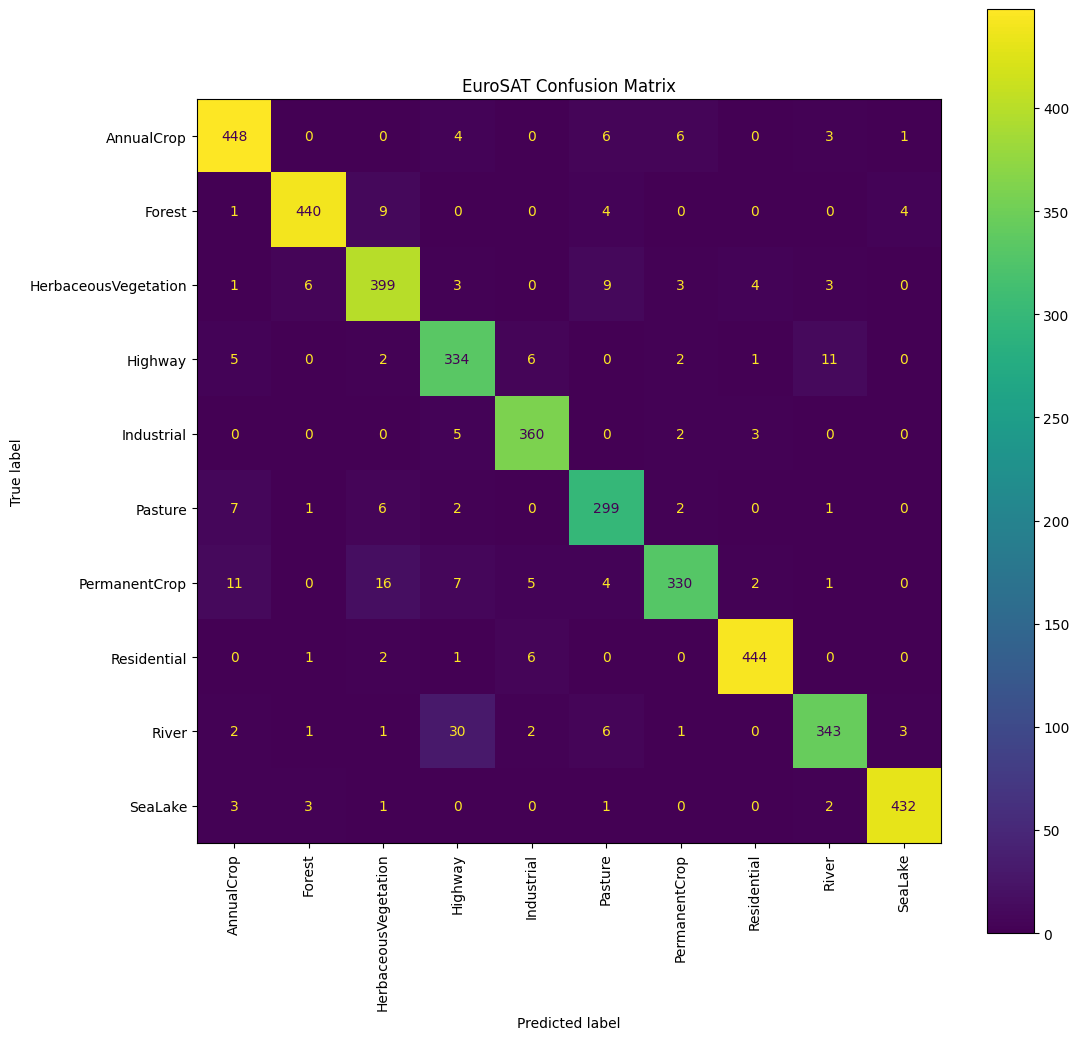

In [20]:
# Build your confusion matrix here
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_sat:
    predictions = model_sat(images, training=False)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions.numpy(), axis=1))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names_sat
)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90)

plt.title("EuroSAT Confusion Matrix")
plt.show()


*Your answer:*

River and Highway get confused most often, which makes visual sense becasue they can both appear simalar from a satellite point of view.


---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |97.12% |94.43% |
| Test Accuracy |97.50% |94.19% |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*
1. The Fire/Smoke dataset is the closet match to to the original training since it has more ground-level photos, while the EuroSAT consists of satellite imagery. The Fire/Smoke model achieved a 97.7% test accuracy while the EuroSAT achieved only 94.19%. The satellite images are a larger mismatch.




---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*
The fire dataset was imbalanced, so it did change how I evaluated the model, paying attention to the confusuion matrix and not just accuracy.

In part 1, I used one output neuron with sigmoid activation and binary cross-entropy since there was only two classes in the fire dataset. In part 2 I used 10 output neurons with softmax activation and sparse categorical cross-entropy since the EuroSAT dataset had 10 different classes.

Based on my results from this assignment, a model with original training that matches the ask can greatly enhance it's usefullnes. Overall a model's usefulness depends on both how good the model is, and also on how well its original training matches your task. In this case the pretrained model matched the Fire dataset better, which resulted in 97.50% test accuracy, while the EuroSAT dataset fell behind with only a 94.19% accuracy.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.